# MLHW 5-3

## Task 0: Load the HTRU2 Dataset

In [16]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context
ctx = ssl._create_unverified_context()
opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=ctx))
urllib.request.install_opener(opener)

from ucimlrepo import fetch_ucirepo

htru2 = fetch_ucirepo(id=372)

X = htru2.data.features
y = htru2.data.targets

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (17898, 8)
y shape: (17898, 1)


In [17]:
print(htru2.metadata)

{'uci_id': 372, 'name': 'HTRU2', 'repository_url': 'https://archive.ics.uci.edu/dataset/372/htru2', 'data_url': 'https://archive.ics.uci.edu/static/public/372/data.csv', 'abstract': 'Pulsar candidates collected during the HTRU survey. Pulsars are a type of star, of considerable scientific interest. Candidates must be classified in to pulsar and non-pulsar classes to aid discovery.', 'area': 'Physics and Chemistry', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 17898, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Wed Apr 03 2024', 'dataset_doi': '10.24432/C5DK6R', 'creators': ['Robert Lyon'], 'intro_paper': {'ID': 460, 'type': 'NATIVE', 'title': 'Fifty years of pulsar candidate selection: from simple filters to a new principled real-time classification approach', 'a

In [18]:
print(htru2.variables)

               name     role        type demographic description units  \
0      Profile_mean  Feature  Continuous        None        None  None   
1     Profile_stdev  Feature  Continuous        None        None  None   
2  Profile_skewness  Feature  Continuous        None        None  None   
3  Profile_kurtosis  Feature  Continuous        None        None  None   
4           DM_mean  Feature  Continuous        None        None  None   
5          DM_stdev  Feature  Continuous        None        None  None   
6       DM_skewness  Feature  Continuous        None        None  None   
7       DM_kurtosis  Feature  Continuous        None        None  None   
8             class   Target      Binary        None        None  None   

  missing_values  
0             no  
1             no  
2             no  
3             no  
4             no  
5             no  
6             no  
7             no  
8             no  


## Task 1: Combine Features and Target, Examine Summary Statistics

In [19]:
import pandas as pd

df = pd.concat([X, y], axis=1)
df[y.columns[0]] = df[y.columns[0]].astype(int)

print("Class distribution:")
print(df[y.columns[0]].value_counts())

Class distribution:
class
0    16259
1     1639
Name: count, dtype: int64


In [20]:
df.describe()

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,class
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709,0.091574
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540,0.288432
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504,0.000000
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556,0.000000
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


## Task 2: Train/Test Split

In [21]:
from sklearn.model_selection import train_test_split
import numpy as np

target_col = y.columns[0]
X_all = df.drop(columns=[target_col])
y_all = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (14318, 8)
X_test:  (3580, 8)
y_train: (14318,)
y_test:  (3580,)


## Task 3: SVM Pipeline with Grid Search

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

param_grid = [
    {'svc__kernel': ['linear'], 'svc__C': [0.1, 1, 10]},
    {'svc__kernel': ['rbf'], 'svc__C': [0.1, 1, 10], 'svc__gamma': [0.01, 0.1, 1]},
    {'svc__kernel': ['poly'], 'svc__C': [0.1, 1, 10], 'svc__gamma': [0.01, 0.1, 1], 'svc__degree': [2, 3]}
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))

Best parameters: {'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Best CV accuracy: 0.9793


## Task 4: Cross-Validation Results and Model Ranking

In [23]:
results = pd.DataFrame(grid_search.cv_results_)

cols = ['rank_test_score', 'mean_test_score', 'std_test_score',
        'param_svc__kernel', 'param_svc__C', 'param_svc__gamma', 'param_svc__degree']
results_summary = results[cols].sort_values('rank_test_score')

results_summary

,rank_test_score,mean_test_score,std_test_score,param_svc__kernel,param_svc__C,param_svc__gamma,param_svc__degree
10,1,0.979257,0.002617,rbf,10.0,0.10,NaN
2,2,0.979187,0.003536,linear,10.0,NaN,NaN
9,3,0.979117,0.002907,rbf,10.0,0.01,NaN
1,4,0.978978,0.003542,linear,1.0,NaN,NaN
17,5,0.978698,0.002913,poly,0.1,1.00,3.0
7,6,0.978279,0.003451,rbf,1.0,0.10,NaN
11,7,0.978140,0.003233,rbf,10.0,1.00,NaN
29,8,0.978000,0.001845,poly,10.0,1.00,3.0
23,9,0.978000,0.001949,poly,1.0,1.00,3.0
0,10,0.977860,0.003769,linear,0.1,NaN,NaN


The best model is RBF (C=10, γ=0.1) at 97.93% CV accuracy, closely followed by linear (C=10) at 97.92%. The top 10 models span < 0.2 pp, suggesting multiple configurations perform comparably. Polynomial kernels with small γ/C rank lowest due to underfitting.

## Task 5: Best Model and Hyperparameters

In [24]:
best_model = grid_search.best_estimator_

print("Best hyperparameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))
print("\nBest estimator:\n", best_model)

Best hyperparameters: {'svc__C': 10, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
Best CV accuracy: 0.9793

Best estimator:
 Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(C=10, gamma=0.1))])


## Task 6: Test Set Evaluation

Test accuracy: 0.9802

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3252
           1       0.93      0.84      0.89       328

    accuracy                           0.98      3580
   macro avg       0.96      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580



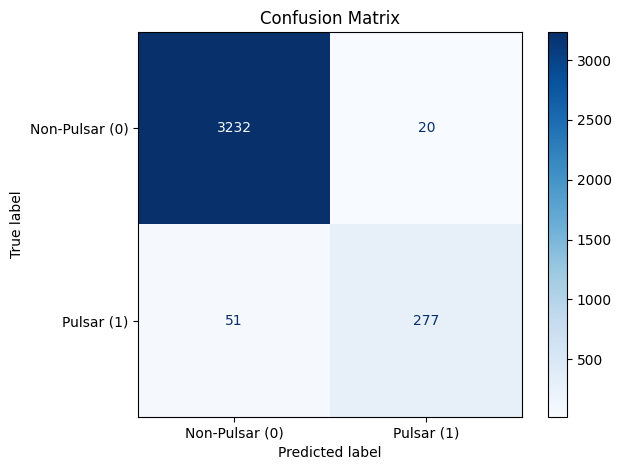

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Pulsar (0)', 'Pulsar (1)'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Test accuracy is 98.02%, consistent with CV. Pulsar recall is 0.84 with precision 0.93 (F1 = 0.89). Errors are dominated by 51 false negatives (true pulsars missed), reflecting the ~9:1 class imbalance.

## Task 7: Permutation Feature Importance

In [26]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_model, X_test, y_test, n_repeats=30, random_state=42, scoring='accuracy', n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X_all.columns,
    'Mean Importance': perm_result.importances_mean,
    'Std Importance': perm_result.importances_std
}).sort_values('Mean Importance', ascending=False)

print(perm_df.to_string(index=False))

         Feature  Mean Importance  Std Importance
Profile_skewness         0.100968        0.002912
Profile_kurtosis         0.024339        0.001535
    Profile_mean         0.017626        0.001269
        DM_stdev         0.012104        0.001454
   Profile_stdev         0.007607        0.001383
     DM_skewness         0.003324        0.001083
     DM_kurtosis         0.002579        0.001275
         DM_mean         0.000596        0.000602


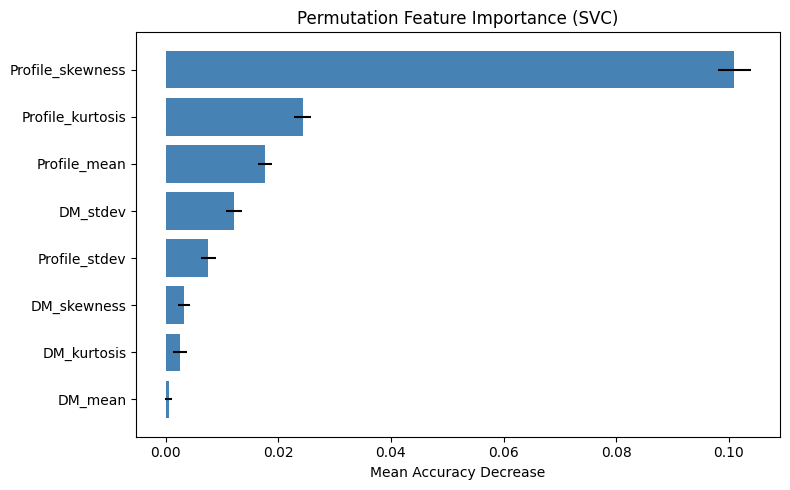

In [27]:
sorted_idx = perm_result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    range(len(sorted_idx)), perm_result.importances_mean[sorted_idx],
    xerr=perm_result.importances_std[sorted_idx], align='center', color='steelblue'
)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels(X_all.columns[sorted_idx])
ax.set_xlabel("Mean Accuracy Decrease")
ax.set_title("Permutation Feature Importance (SVC)")
plt.tight_layout()
plt.show()

## Task 8: Interpretation of Permutation Feature Importance

**Profile_skewness** is the dominant predictor (importance ≈ 0.101), far exceeding all others. **Profile_kurtosis** and **Profile_mean** are secondary contributors. Among DM features, only **DM_stdev** has modest importance; the rest are near zero. This indicates that pulse profile shape statistics — especially asymmetry — are the primary signals for pulsar detection, while DM-SNR features play a limited role.